# Ирисы Фишера - обучение логистической регрессии

In [1]:
# Установка зависимостей
!pip install -q scikit-learn numpy pandas seaborn phik joblib

In [2]:
# Инициализация библиотек
import matplotlib as mpl
mpl.rcParams['figure.constrained_layout.use'] = True

import pandas as pd
import phik
import joblib

In [3]:
# Импорт датасета
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)

iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [4]:
# Выведем текстовое описание датасета
print('Описание датасета:')
print(iris.DESCR)

Описание датасета:
.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for eac

In [5]:
# Соберем данные вместе с целевым признаком для анализа
iris_df = iris.data.join(iris.target)

# Посмотрим на первые несколько строк
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


**Промежуточный вывод:** датасет Iris небольшой (всего 150 наблюдений), но для начала изучения и первых экспериментов с машинным обучением он отлично подходит.

Также в данных нет выбросов, дубликатов и пропущенных значений - это упрощает процесс EDA

Посмотрим на распределение признаков по классам

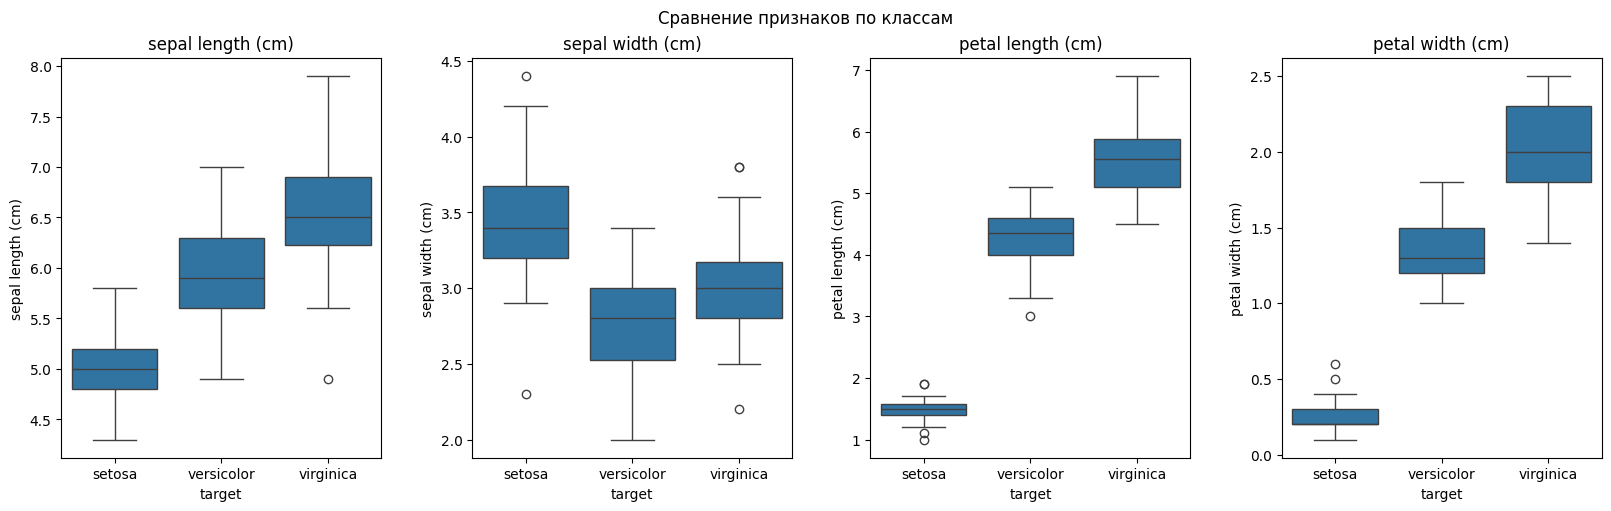

In [6]:
# Построим boxplot по каждому числовому признаку
import matplotlib.pyplot as plt
import seaborn as sns

features_len = len(iris.feature_names)

fig, axes = plt.subplots(
    1,
    features_len,
    figsize=(features_len * 4, 5)
)

fig.suptitle('Сравнение признаков по классам')

for i, feature in enumerate(iris.feature_names):
    sns.boxplot(
        x=iris_df['target'].map(dict(enumerate(iris.target_names))),
        y=iris_df[feature],
        ax=axes[i]
    )

    axes[i].set_title(feature)

fig.set_constrained_layout_pads( wspace=0.1)
plt.show()

Уже по графикам выше видно, что классы хорошо разделяются. Ящики почти не пересекаются, сильнее пересекаются усы и единичные значения выходящие за межквартильный размах.

Построим еще графики корреляций. Для всех видов в общем и по каждому виду отдельно

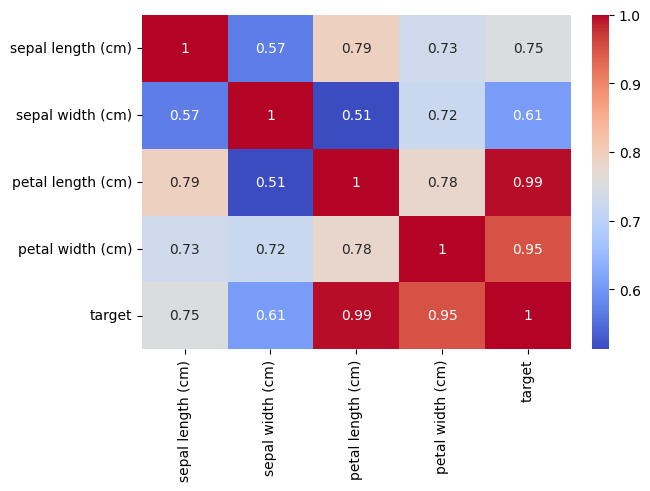

In [7]:
# Общий график корреляции
sns.heatmap(
    iris_df.phik_matrix(interval_cols=iris_df.drop(columns=['target']).columns),
    annot=True,
    cmap='coolwarm'
)
plt.show()

Phik показывает корреляцию даже выше чем заявлено в описании датасета. Данные на полученной тепловой карте хорошо коррелируют с данными полученными из ящиков с усами. Чем меньше пересчение ящиков и их усов, тем выше корреляция. Поэтому для обучения моделей может быть вполне достаточно двух признаков `petal length (cm)` и `petal width (cm)`

Посмотрим, дадут ли дополнительную информацию отдельные тепловые карты по каждому таргету

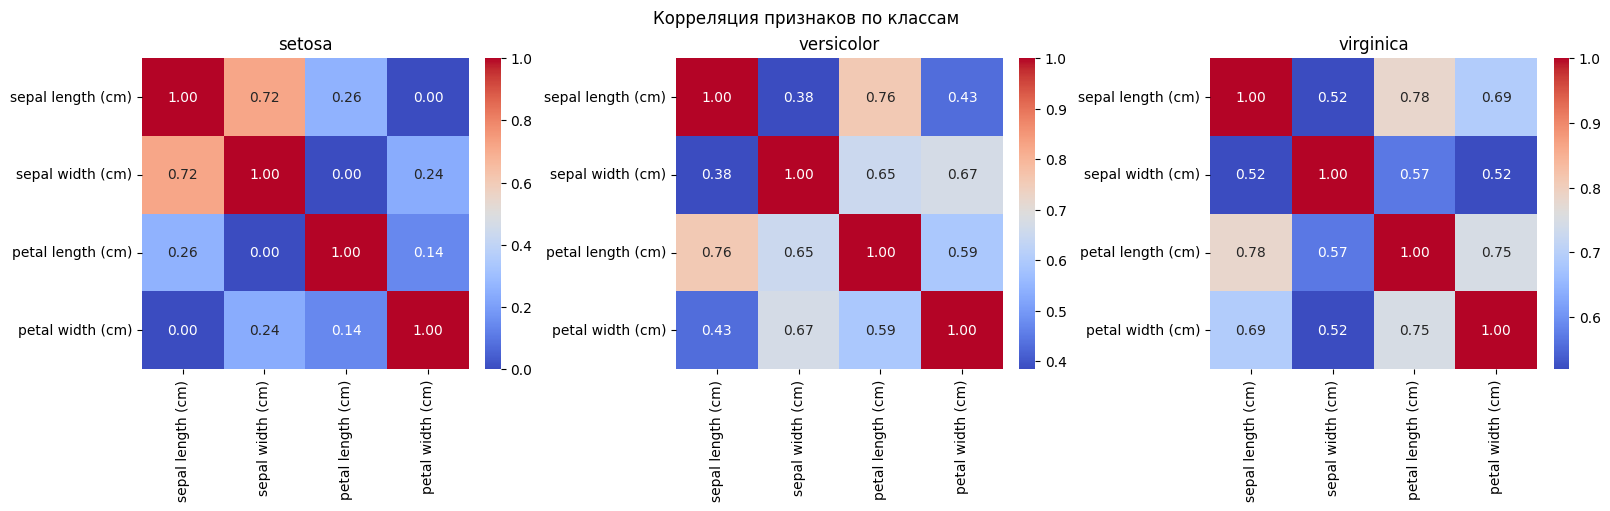

In [8]:
# Отдельная тепловая карта на каждый таргет

fig, axes = plt.subplots(
    1,
    3,
    figsize=(features_len * 4, 5)
)

fig.suptitle('Корреляция признаков по классам')

for i, feature in enumerate(iris.target_names):
    sns.heatmap(
        iris_df[iris_df['target'] == i].drop(columns=['target']).phik_matrix(interval_cols=iris_df.columns),
        annot=True,
        cmap='coolwarm',
        ax=axes[i],
        fmt=".2f"
    )

    axes[i].set_title(feature)

plt.show()

Для каждого класса тепловая карта сильно отличается. Можно сделать вывод, что в данных достаточно информации для классификации.

Посмотрим дополнительно на то как площадь petal и sepal коррелирует с target

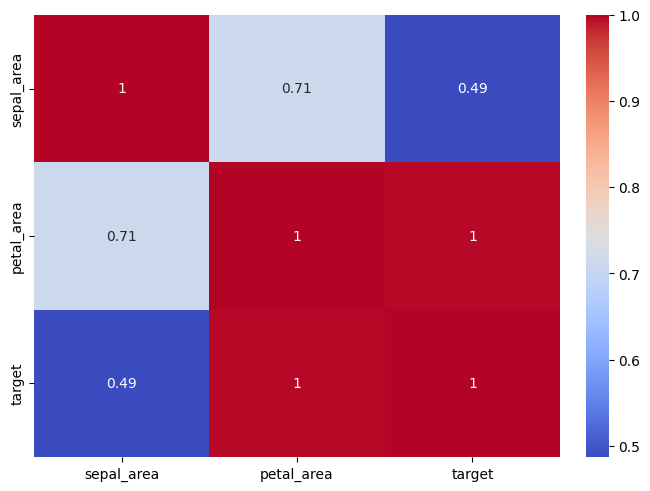

In [9]:
# Добавим признаки площадей чашелистика и лепестка
iris_df_areas = pd.DataFrame({
    'sepal_area': iris_df['sepal length (cm)'] * iris_df['sepal width (cm)'],
    'petal_area': iris_df['petal length (cm)'] * iris_df['petal width (cm)'],
    'target': iris_df['target']
})
sns.heatmap(
    iris_df_areas.phik_matrix(interval_cols=['sepal_area', 'petal_area']),
    annot=True,
    cmap='coolwarm'
)
plt.show()

Сразу становится заметна идеальная корреляция между площадью petal (лепестка) и видом цветка. Посмотрим еще раз на ящики с усами, но теперь по площади petal_area

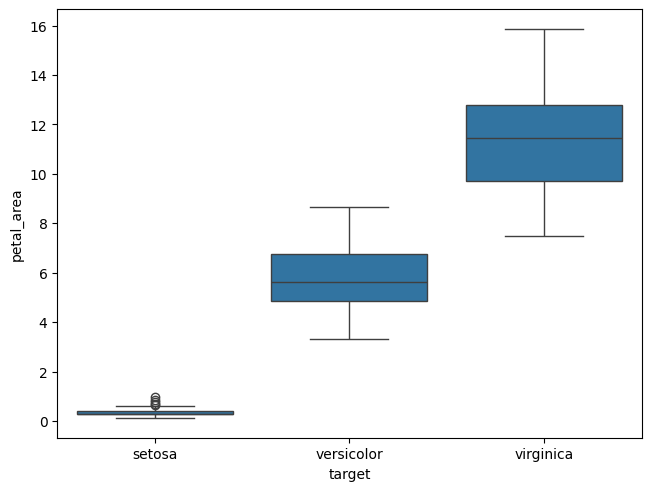

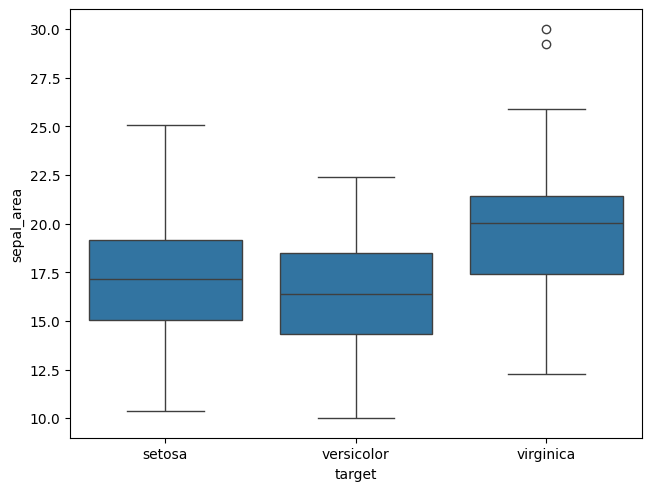

In [10]:
# Сравним распределения площадей по классам
sns.boxplot(
    x=iris_df_areas['target'].map(dict(enumerate(iris.target_names))),
    y=iris_df_areas['petal_area'],
)
plt.show()

sns.boxplot(
    x=iris_df_areas['target'].map(dict(enumerate(iris.target_names))),
    y=iris_df_areas['sepal_area'],
)
plt.show()

# Обучение модели

In [11]:
# Разделение данных на train и test.
# Отдельную validation-выборку не выделяем, так как для подбора гиперпараметров используется кросс-валидация (GridSearchCV) на train.
from sklearn.model_selection import train_test_split

X = iris_df.drop(columns=['target'])
y = iris_df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True,
    random_state=42,
    stratify=y
)

len(X_train), len(X_test)

(120, 30)

In [12]:
# Соберем пайплайн с генерацией новых признаков и логистической регрессией
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import FunctionTransformer

from features import make_areas, areas_feature_names_out

model = Pipeline([
    ('preprocessing', FunctionTransformer(
        make_areas,
        feature_names_out=areas_feature_names_out
    )),
    ('model', LogisticRegression())
])

<module 'pandas' from '/Users/a1/Desktop/learning/ml_for_newbie/linear-regression-experiments/venv/lib/python3.14/site-packages/pandas/__init__.py'>


In [13]:
# Обучим модель на тренировочной выборке
model.fit(X_train, y_train)
,

''

In [14]:
# Оценим качество модели с помощью кросс-валидации
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=5,
    scoring='f1_macro'
)

In [15]:
# Посчитаем средний F1-score по фолдам
cv_results['test_score'].mean()

np.float64(0.9749019607843138)

In [16]:
# Получим предсказания на тестовой выборке и измерим итоговый F1-score
from sklearn.metrics import f1_score

y_pred = model.predict(X_test)

f1_score(y_test, y_pred, average='macro')

1.0

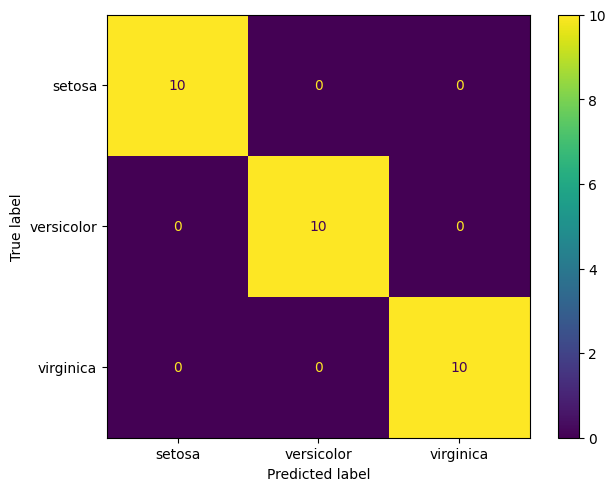

In [17]:
# Построим матрицу ошибок для тестовой выборки
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=iris.target_names
)

plt.show()

Тестовая выборка показала идеальный результат, хотя на кросс валидации было чуть хуже. Построим матрицу ошибок модели на всем датасете

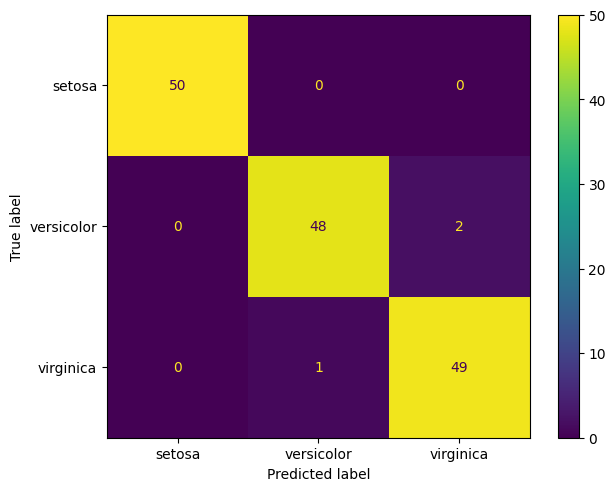

In [18]:
# Построим матрицу ошибок на всех доступных данных
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y,
    model.predict(X),
    display_labels=iris.target_names
)

plt.show()

Как и было видно в процессе исследования данных, возможно возникновение ошибок при отличии versicolor от virginica. Здесь модель ошиблась 3 раза

**Вывод** 

На примере датасета Iris попробовали задачу многоклассовой классификации с помощью логистической регрессии. Даже на простых признаках и их производных модель показала высокое качество и хорошо разделила классы.

## Экспорт модели

In [21]:
# Экспорт модели и метаданных в файл
from datetime import datetime
import sklearn
import sys

# Подготовка метаданных
metadata = {
    'model_version': '1.0',
    'training_date': datetime.now().strftime('%Y-%m-%d'),
    'features': ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'],
    'sklearn_version': sklearn.__version__,
    'python_version': f"{sys.version_info.major}.{sys.version_info.minor}"
}

print(metadata)

joblib.dump({
    'model': model,
    'metadata': metadata
}, 'model.joblib')

{'model_version': '1.0', 'training_date': '2026-05-29', 'features': ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'], 'sklearn_version': '1.6.1', 'python_version': '3.14'}


['model.joblib']

In [20]:
iris_df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='str')